SEABORN INTRO

In [8]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast

# Loading Data 
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) # Convert string representation of list to actual list

Install and Import Seaborn

In [9]:
import seaborn as sns

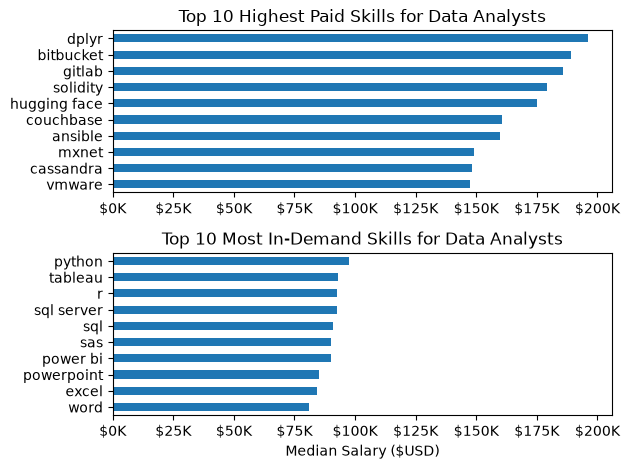

In [10]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] =='Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

# Explode job_skills column
df_DA_US = df_DA_US.explode('job_skills')

# group by skills and get the median salary and count for each skill
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

# create new df for top 10 skills with highest median salary
df_DA_top_pay = df_DA_US_group.sort_values(by='median', ascending=False).head(10)

# create new df for top 10 skills with highest count
df_DA_skills = df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)


# plotting both in same visualization
fig, ax = plt.subplots(2,1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()

Alter Plots using Seaborn

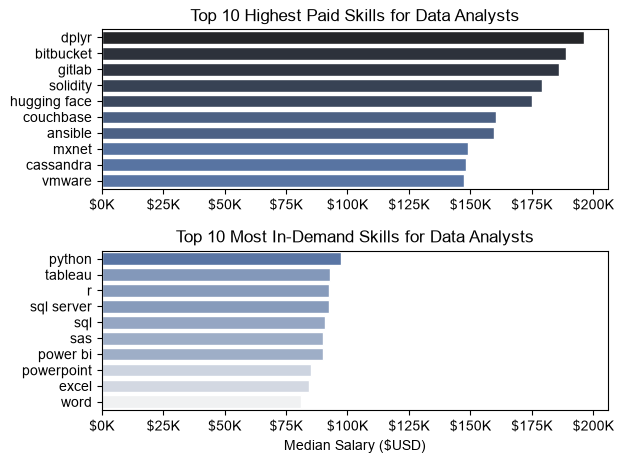

In [18]:
# Reverse the index for plotting
top_pay_order = df_DA_top_pay.index[::-1]
skills_order = df_DA_skills.index[::-1]

fig, ax = plt.subplots(2,1)

sns.set_theme(style="ticks")

# Top 10 Highest Paid Skills for Data Analyst
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, order = top_pay_order, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()


#df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analyst
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, order = skills_order, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()

#df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()

Seaborn - Histograms

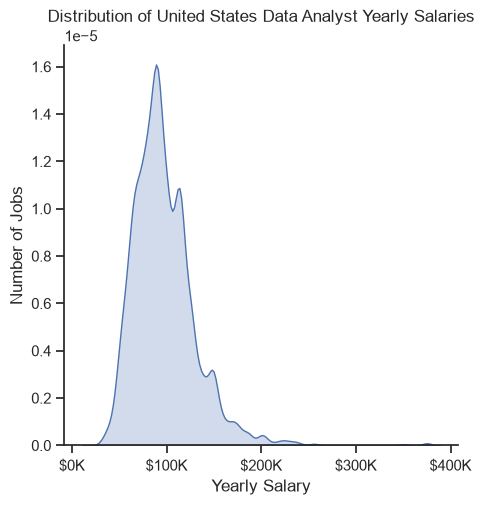

In [22]:
# Creating a histogram
#df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

# Plotting Histogram with Seaborn
sns.set_theme(style="ticks")
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.show()

Seaborn - Boxplots

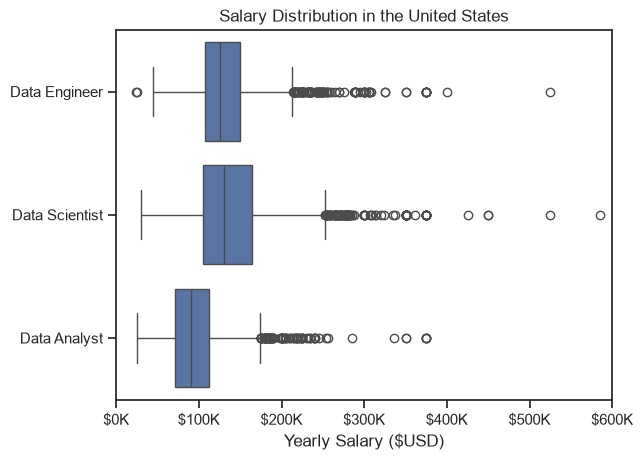

In [26]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# Only get data analyst, data scientist, and data engineer jobs in the US
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')

plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.xlim(0,600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()